In [1]:
# Imports

import os
import random
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

import matplotlib.pyplot as plt

# Reproducibility

SEED = 10

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Imports Loaded")

Imports Loaded


In [2]:
# Dataset Paths

train_dir = r"C:\ML Projects\Medical-Image-Classification-Projects\Exersize-1(BrainTumour-SVM)\archive\Training"

test_dir = r"C:\ML Projects\Medical-Image-Classification-Projects\Exersize-1(BrainTumour-SVM)\archive\Testing"

IMG_SIZE = (224,224)

BATCH_SIZE = 32


# Generators

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Generators Created")

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.
Generators Created


In [3]:
# Transfer Learning MobileNet

base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers

base_model.trainable = False


x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

predictions = Dense(
    4,
    activation='softmax'
)(x)


model = Model(
    inputs=base_model.input,
    outputs=predictions
)

model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning Model Ready")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 114s 7us/step
Transfer Learning Model Ready


# Transfer Learning Model Creation

We now create the transfer learning model.

Changes from Baseline CNN:

* Use pretrained ImageNet weights
* Freeze pretrained convolution layers
* Replace binary classifier with multi-class classifier
* Output classes changed from 2 → 4

This allows previously learned visual features to be reused for the brain tumor classification task.


In [4]:
# Model Summary

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,232,964 (12.33 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

# Compile Transfer Learning Model

The pretrained MobileNet feature extractor is frozen.

Only the final classification layer is trainable.

The model is compiled using:

* Adam optimizer
* Categorical crossentropy loss
* Accuracy metric

This configuration is suitable for multi-class brain tumor classification.


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled")

Model Compiled


# Transfer Learning Training

The transfer learning model is now trained.

Configuration:

* Frozen MobileNet backbone
* Only classifier head trains
* Multi-class classification
* Initial training performed for 10 epochs

The objective is to establish a transfer learning baseline before further fine-tuning.


In [6]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 371ms/step - accuracy: 0.5655 - loss: 1.0620 - val_accuracy: 0.7243 - val_loss: 0.6737
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 362ms/step - accuracy: 0.7758 - loss: 0.5782 - val_accuracy: 0.7592 - val_loss: 0.5653
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 345ms/step - accuracy: 0.8346 - loss: 0.4521 - val_accuracy: 0.8168 - val_loss: 0.4773
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 317ms/step - accuracy: 0.8563 - loss: 0.4077 - val_accuracy: 0.8202 - val_loss: 0.4560
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 334ms/step - accuracy: 0.8737 - loss: 0.3460 - val_accuracy: 0.8412 - val_loss: 0.4319
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 340ms/step - accuracy: 0.8816 - loss: 0.3266 - val_accuracy: 0.8429 - val_loss: 0.4016
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 344ms/step - accuracy: 0.8946 - loss: 0.3030 - val_accuracy: 0.8551 - val_loss: 0.3837
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 340ms/step - accuracy: 0.8986 - loss: 0.2851 - val_accu

# Initial Transfer Learning Observations

Observations from initial training:

* Training accuracy improved steadily across epochs
* Validation accuracy increased from approximately 72% to 84%
* Validation loss decreased significantly during training
* Transfer learning converged considerably faster compared to training CNN models from scratch

Conclusion:

Pretrained features from MobileNet appear effective for brain tumor classification.


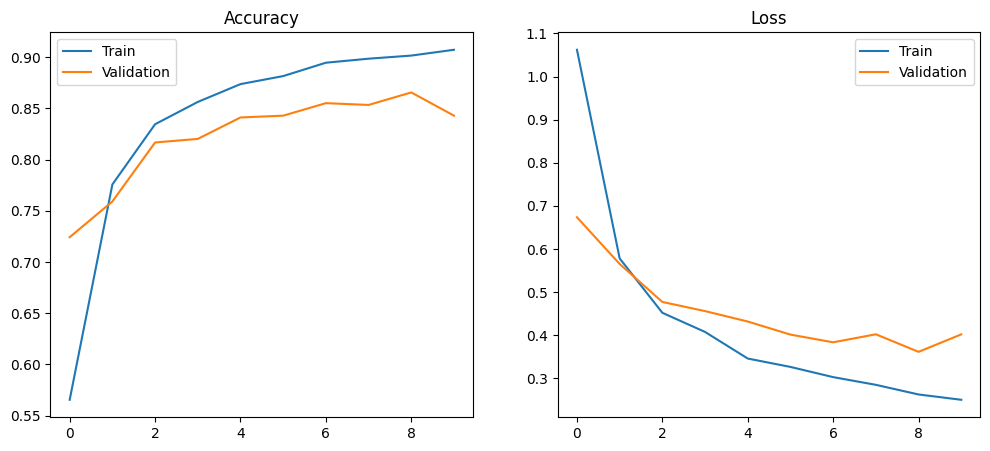

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")

plt.legend(['Train','Validation'])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Loss")

plt.legend(['Train','Validation'])

plt.show()

# Training Curve Observations

Accuracy Analysis:

* Training accuracy steadily increased throughout training
* Validation accuracy improved consistently and stabilized near 85%
* Small gap between training and validation curves indicates acceptable generalization

Loss Analysis:

* Training loss decreased continuously
* Validation loss generally decreased with small fluctuations
* Slight increase near final epochs may indicate early overfitting

Conclusion:

Transfer learning training behavior appears stable and suitable for evaluation.


In [8]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

print("Test Loss:", test_loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.7056 - loss: 1.0630
Test Accuracy: 0.7055837512016296
Test Loss: 1.0629674196243286


# Initial Test Performance Observation

Results show:

* Training accuracy approximately 91%
* Validation accuracy approximately 85%
* Test accuracy approximately 71%

Observation:

A noticeable gap exists between validation and testing performance.

Possible reasons include:

* Class imbalance
* Distribution differences between testing and training data
* Increased difficulty due to multi-class classification

Further analysis using confusion matrices is required.


In [9]:
predictions = model.predict(test_generator)

pred_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_generator.classes

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step


# Multi-Class Evaluation

The model predictions are converted into class labels.

Evaluation includes:

* Confusion Matrix
* Precision
* Recall
* F1-score
* Per-class performance analysis

These metrics provide deeper insight beyond overall accuracy.


In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(
    true_classes,
    pred_classes
)

print("CONFUSION MATRIX")

print(cm)

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=test_generator.class_indices.keys()
    )
)

CONFUSION MATRIX
[[ 25  49  22   4]
 [  2 103  10   0]
 [  5   7  92   1]
 [  0  10   6  58]]

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    glioma_tumor       0.78      0.25      0.38       100
meningioma_tumor       0.61      0.90      0.73       115
        no_tumor       0.71      0.88      0.78       105
 pituitary_tumor       0.92      0.78      0.85        74

        accuracy                           0.71       394
       macro avg       0.75      0.70      0.68       394
    weighted avg       0.74      0.71      0.68       394

